In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt

In [25]:
# dataframe will be used to plot heatmap
df_hourly_stats = pd.read_parquet('../data/processed/hourly_stats.parquete')

In [3]:
cc_trips = pd.read_parquet('../data/processed/cleaned_credit_card_trips.parquet')
cc_trips.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,pickup_hour,pickup_day,tip_percentage
0,2,2026-01-01 00:54:04,2026-01-01 00:59:37,1.0,0.97,1.0,N,239,238,1,...,3.66,0.0,1.0,15.86,2.5,0.0,0.00,0,Thursday,50.83
1,2,2026-01-01 00:15:22,2026-01-01 00:58:10,4.0,5.58,1.0,N,142,209,1,...,11.11,0.0,1.0,55.56,2.5,0.0,0.75,0,Thursday,28.71
2,2,2026-01-01 00:47:11,2026-01-01 01:00:47,2.0,2.33,1.0,N,144,137,1,...,4.99,0.0,1.0,24.94,2.5,0.0,0.75,0,Thursday,35.14
3,2,2026-01-01 00:34:14,2026-01-01 01:11:58,1.0,5.34,1.0,N,161,45,1,...,8.61,0.0,1.0,51.66,2.5,0.0,0.75,0,Thursday,23.08
4,2,2026-01-01 00:41:07,2026-01-01 00:50:42,3.0,1.83,1.0,N,237,263,1,...,2.36,0.0,1.0,18.06,2.5,0.0,0.00,0,Thursday,22.06


### Target Creation & Class Imbalance

In [4]:
# Determining generous tip
cc_trips['is_generous_tip'] = (cc_trips['tip_percentage'] > 20).astype(int)
cc_trips['is_generous_tip']

# Generous tip distribution
generous_dist = cc_trips['is_generous_tip'].value_counts(normalize = True)*100
generous_dist.head()

is_generous_tip
1    72.920279
0    27.079721
Name: proportion, dtype: float64

### Feature Engineering, Splitting, and Scaling

In [5]:
# Duration in minutes
cc_trips['trip_duration'] = (cc_trips['tpep_dropoff_datetime'] - cc_trips['tpep_pickup_datetime']).dt.total_seconds() / 60.0

# Defining features and target
features = ['trip_distance', 'fare_amount', 'trip_duration', 'pickup_hour']
X = cc_trips[features]
y = cc_trips['is_generous_tip']

# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

### Model Training, Evaluation, and Business Insight

In [6]:
# model training
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# Prediction
y_pred = model.predict(X_test_scaled)

# evaluation
print(f'Accuracy Score {accuracy_score(y_test, y_pred)}')
print(f'Classification Report {classification_report(y_test, y_pred)}')

Accuracy Score 0.7493925774998986
Classification Report               precision    recall  f1-score   support

           0       0.68      0.13      0.22    119603
           1       0.75      0.98      0.85    324075

    accuracy                           0.75    443678
   macro avg       0.72      0.55      0.54    443678
weighted avg       0.73      0.75      0.68    443678



### Advanced Modeling & Interpretability

### Extracting Logistic Regression Insights

In [7]:
# Extracting coefficients (model.coef_[0])
coefficients = model.coef_[0]

# Matching coefficients to a datframe
df_coefficients = pd.DataFrame({
    'Features': features,
    'Coefficients': coefficients
})
df_coefficients_sorted = df_coefficients.sort_values(by='Coefficients', ascending=False)

strongest_positive = df_coefficients_sorted.loc[df_coefficients_sorted['Coefficients'].idxmax(), ['Features', 'Coefficients']]
strongest_positive
print(f'{strongest_positive['Features']} has the strongest positive coefficient {strongest_positive['Coefficients']} which makes sense')

fare_amount has the strongest positive coefficient 0.1704791253623587 which makes sense


### Upgrading to an Ensemble Model (Random Forest)

In [8]:
# Instantiate and train Random Forest
model_rf = RandomForestClassifier(n_estimators=100,max_depth=10, random_state=42,n_jobs=-1)
model_rf.fit(X_train_scaled, y_train)

# predicting
y_pred_rf = model_rf.predict(X_test_scaled)


In [9]:
# Classification report
print(f'Classification report\n: {classification_report(y_test, y_pred_rf)}')

Classification report
:               precision    recall  f1-score   support

           0       0.65      0.19      0.30    119603
           1       0.76      0.96      0.85    324075

    accuracy                           0.75    443678
   macro avg       0.71      0.58      0.57    443678
weighted avg       0.73      0.75      0.70    443678



### Visualization

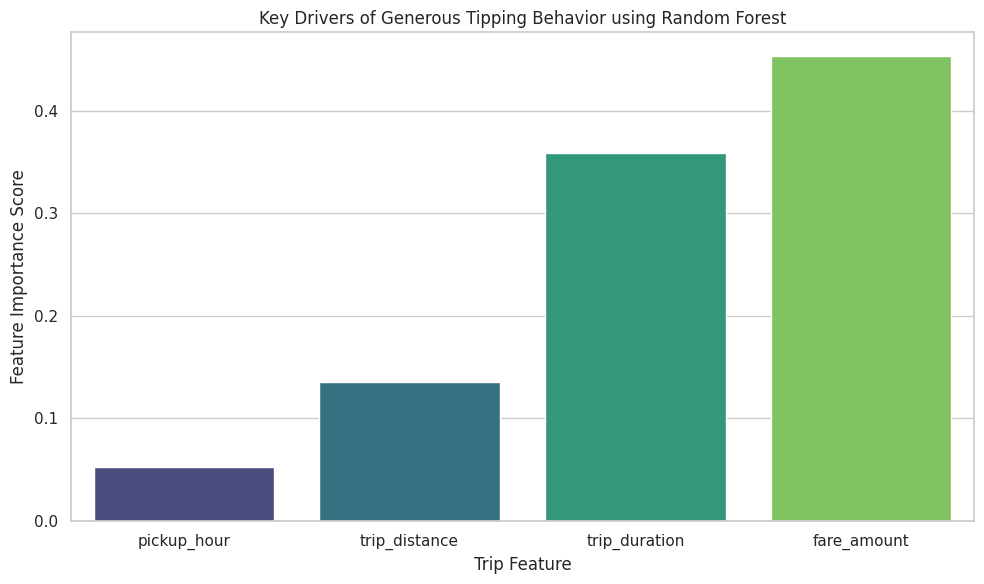

In [23]:
# Extracting feature importance from rf model
importance = model_rf.feature_importances_

# Creating a df and sorting in ascending
df_importance = pd.DataFrame({
    'Feature': features,
    'Importance': importance
}).sort_values(by = 'Importance', ascending = True)

sns.set_theme(style = 'whitegrid')
plt.figure(figsize = (10,6))

sns.barplot(
    x = 'Feature',
    y = 'Importance',
    data = df_importance,
    legend= False,
    hue= 'Feature',
    palette = 'viridis'
)

plt.title('Key Drivers of Generous Tipping Behavior using Random Forest')
plt.xlabel('Trip Feature')
plt.ylabel('Feature Importance Score')
plt.tight_layout()

plt.savefig('../images/generous_tipping_drivers.png', dpi = 300, bbox_inches = 'tight')

plt.show()

### Weekly Demand & Fare Heatmap

In [30]:
# 1. Reset the index first to guarantee 'day_of_week' is accessible as a column
hourly_stats_reset = df_hourly_stats.reset_index()

# 2. Pivot using the reset DataFrame
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_data = hourly_stats_reset.pivot(index='day_of_week', columns='pickup_hour', values='avg_fare')

# 3. Reindex to make sure the days display in correct calendar order (Mon-Sun)
heatmap_data = heatmap_data.reindex(day_order)

# 2. Set up the plotting canvas
plt.figure(figsize=(14, 7))

# 3. Create the heatmap with a warm color scale representing money
sns.heatmap(
    heatmap_data, 
    cmap='YlGnBu', 
    annot=False, # Set to True if you want to see exact dollar numbers inside every square
    linewidths=.5,
    cbar_kws={'label': 'Average Fare Amount ($)'}
)

# 4. Clean up labels to guarantee clean presentation
plt.title('NYC Taxi High-Value Zones: Average Fare by Day and Hour', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Hour of the Day (00:00 - 23:00)', fontsize=12, labelpad=10)
plt.ylabel('Day of the Week', fontsize=12, labelpad=10)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()

plt.savefig('../images/weekly_demand.png', dpi = 300, bbox_inches = 'tight')

KeyError: 'day_of_week'